###1.데이터를 가져오기 위해 깃허브와 연동

In [ ]:
!git clone 'https://'github.com/KangKyungHwa/DSMH/''

Cloning into 'DSMH'...
remote: Enumerating objects: 379, done.
remote: Counting objects: 100% (121/121), done.
remote: Compressing objects: 100% (104/104), done.
remote: Total 379 (delta 67), reused 13 (delta 13), pack-reused 258 (from 1)
Receiving objects: 100% (379/379), 18.91 MiB | 29.74 MiB/s, done.
Resolving deltas: 100% (178/178), done.


###2.한글깨짐 방지를 위해 폰트 설정

In [ ]:
# 1. 나눔고딕 폰트 설치
!sudo apt-get update -qq
!sudo apt-get install -y fonts-nanum-extra -qq

# 2. 시스템 폰트 캐시 업데이트
!sudo fc-cache -fv

# 3. Matplotlib 폰트 캐시 삭제
!rm -rf ~/.cache/matplotlib

###3.깃허브의 titanic_full.csv 파일 불러오기

In [ ]:
import pandas as pd      # pd  라는 별칭으로 pandas의 기능에 접근
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno  # 결측값을 시각적으로 탐색하고 분석하는 데 사용되는 라이브러리

df = pd.read_csv("DSMH/example_data/sample_5/titanic_full.csv")
print(df.head())

###   4.결측치 탐색: 데이터에서 결측치가 있는지 확인

In [ ]:
df.isnull().sum()

### 5.Age, Cabin 등의  값에서 결측치 확인

In [ ]:
df.info()

 ### 6.Age와 Cabin의 결측상태 시각화

<Axes: >

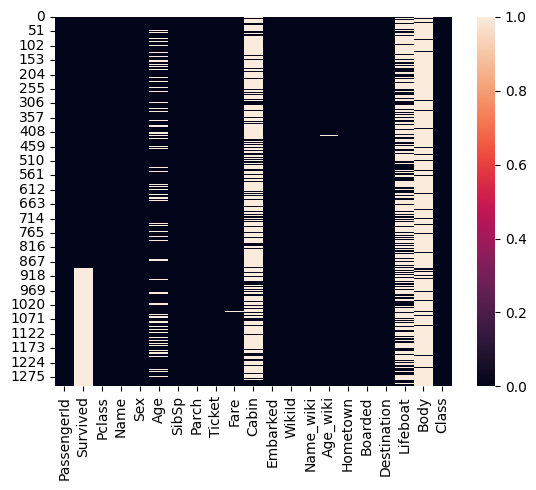

In [ ]:
sns.heatmap(df.isnull())

### 7.원본 파일은 만일을 위해 저장하고 복사한 파일에 결측값을 채우기

In [ ]:
test_df=df.copy() #원본파일 저장
                  # 테스트를 위해 test_df 데이터를 활용
test_df2=test_df
test_df3 = df.copy()
# 데이터가 저장된 메모리 주소 반환
print(id(df))
print(id(test_df))
print(id(test_df2))
print(id(test_df3))


###8.데이터프레임 df의 결측치 패턴을 시각화

<Axes: >

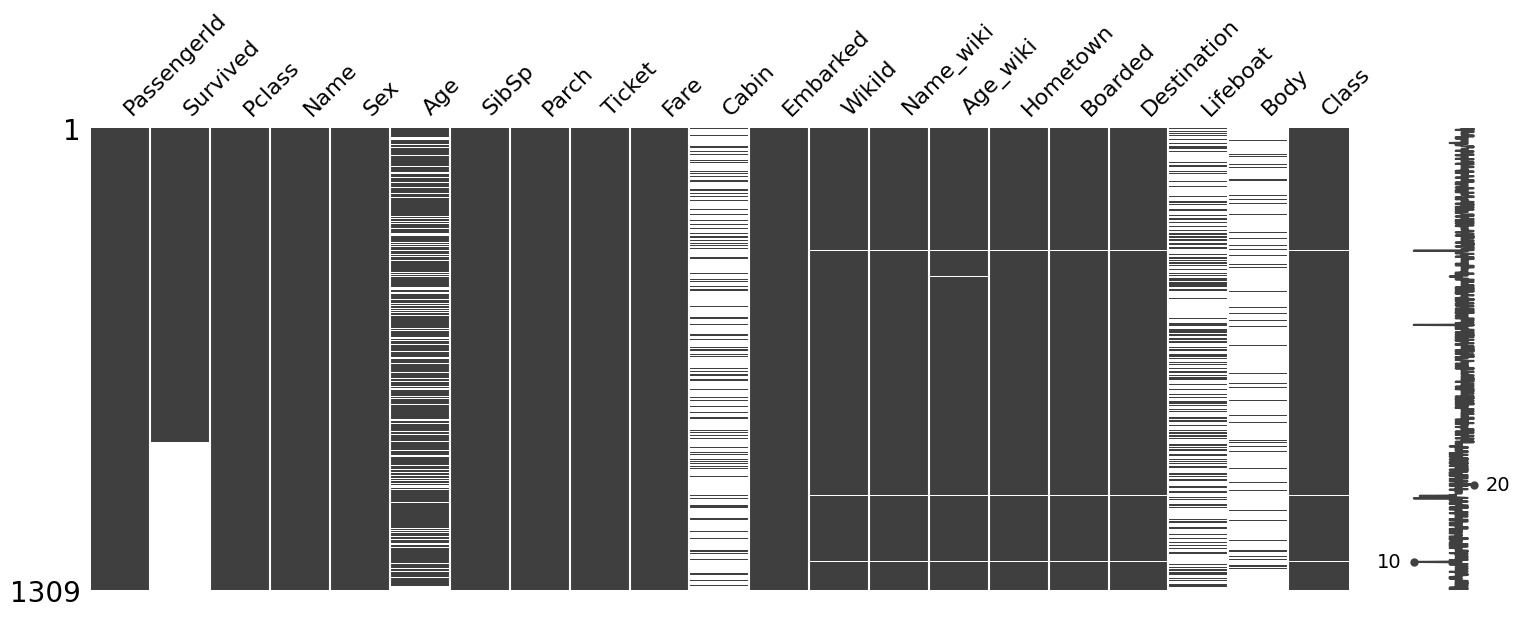

In [ ]:
msno.matrix(df,figsize=(18,6))

### 9.null 값이 있는 위치를 확인

In [ ]:
df[df["Age"].isna()].index

Index([   5,   17,   19,   26,   28,   29,   31,   32,   36,   42,
       ...
       1256, 1257, 1271, 1273, 1275, 1299, 1301, 1304, 1307, 1308],
      dtype='int64', length=263)

In [ ]:
null_idx=df[df["Age"].isna()].index
print(null_idx)

Index([   5,   17,   19,   26,   28,   29,   31,   32,   36,   42,
       ...
       1256, 1257, 1271, 1273, 1275, 1299, 1301, 1304, 1307, 1308],
      dtype='int64', length=263)


In [ ]:
df.loc[null_idx]  # 나이의 결측치 값을 null_idx에서 확인

### 10.결측치 모든 데이터를 보고 싶을 때 활용

In [ ]:
import pandas as pd

# pandas 출력 설정 변경: 모든 행과 열을 표시하도록 설정
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# 전체 DataFrame 출력
display(df.loc[null_idx])

# 설정 초기화 (선택 사항: 다음 작업에 영향을 주지 않으려면 초기화하는 것이 좋습니다)
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

###11.나이값에 0 채우기 연습

In [ ]:
test_df["Age"].fillna(0)

####12. 데이터의 분포 모양 알기

array([[<Axes: title={'center': 'Age'}>]], dtype=object)

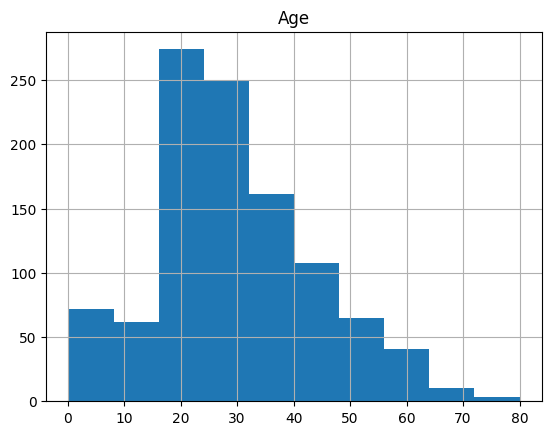

In [ ]:
test_df.hist("Age")  # 나이의 히스토그램을 보면 정규분포 모양을 따르지 않는다

###13.나이의 결측값에 중앙값을 넣어준다

In [ ]:
test_df["Age"].fillna(test_df["Age"].median(),inplace=True)

# 정규분포와 비슷하지 않으므로 중앙값을 결측값에 넣어준다.
# 1304번째 결측값이 중앙값 28로 채워진 것을 확인할 수 있다
print("Median:", test_df["Age"].median() , "\n")
print(test_df)

###14.Fare의 최빈값 , 결측값 합계 구하기

In [ ]:
Fare_mode =test_df["Fare"].mode()[0]    # Fare 의 최빈값 계산
test_df["Fare"].fillna(Fare_mode, inplace=True)
print(Fare_mode)
print(test_df["Fare"].isnull().sum())  # Fare의 결측값 합계
test_df.head()

### 15. Embarked 값 확인

In [ ]:
test_df["Embarked"].value_counts() # Embarked 값 확인

,count
Embarked,
S,914
C,270
Q,123
Unknown,2


###16. Embarked 의 결측값 갯수 확인

In [ ]:
test_df["Embarked"].isna().sum()  # 결측값 갯수 확인

np.int64(0)

###17. Embarked 의 결측값이 있는 위치 찾기

In [ ]:
test_df[test_df["Embarked"].isna()].index  # Embarked 의 결측값이 있는 위치를 찾는다
display(test_df.loc[61])                   # 찾은 위치를 나타낸다
test_df["Embarked"].fillna("Unknown",inplace=True)
#inplace=True는 원본데이터 값을 직접 수정하도록 지시


,61
PassengerId,62
Survived,1.0
Pclass,1
Name,"Icard, Miss. Amelie"
Sex,female
Age,38.0
SibSp,0
Parch,0
Ticket,113572
Fare,80.0


### 18.데이터의 컬럼들을 가져온다

In [ ]:
test_df3.columns   # 데이터의 컬럼들을 가져온다

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'WikiId', 'Name_wiki',
       'Age_wiki', 'Hometown', 'Boarded', 'Destination', 'Lifeboat', 'Body',
       'Class'],
      dtype='object')

###19.컬럼들을 columns 에 넣어둔다

In [ ]:
columns=test_df3.columns # 컬럼들을 columns 에 넣어둔다

###20.column 한 개 제거해 보기

In [ ]:
columns[:-1] # column 한 개 제거

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'WikiId', 'Name_wiki',
       'Age_wiki', 'Hometown', 'Boarded', 'Destination', 'Lifeboat', 'Body'],
      dtype='object')

###21. column 3 개 제거

In [ ]:
columns[:-3]  # column 3 개 제거

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'WikiId', 'Name_wiki',
       'Age_wiki', 'Hometown', 'Boarded', 'Destination'],
      dtype='object')

###22.분석에 필요없을 것 같은 'Cabin' 컬럼의 모든 데이터를 결측값(데이터 없음)으로 명시적으로 설정

In [ ]:
test_df3["Cabin"]=pd.NA  # Cabin 에 Not Available 넣어준다

###23. 결측값의 총 개수 확인해 보기

In [ ]:
test_df3.isna().sum()

###24.필요없다면 NA 를 넣어준  Cabin column 열을 제거한다

In [ ]:
test_df3.dropna(axis="columns")  #NA 를 넣어준  Cabin column 열이 제거된다

###25.결측값 열, 행 제거방법

In [ ]:
test_df3.dropna(axis="columns")  #결측값이 있는 열 전체를 제거

In [ ]:
test_df3.dropna(axis="index")    #결측값이 있는 행 전체 제거

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Embarked,WikiId,Name_wiki,Age_wiki,Hometown,Boarded,Destination,Lifeboat,Body,Class


###26. 원본 데이터 확인해 보기

In [ ]:
df.describe(include="all")  # 숫자형, 문자형등 모든 데이터 설명

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Embarked,WikiId,Name_wiki,Age_wiki,Hometown,Boarded,Destination,Lifeboat,Body,Class
count,1309.000000,891.000000,1309.000000,1309,1309,1046.000000,1309.000000,1309.000000,1309,1308.000000,...,1307,1304.000000,1304,1302.000000,1304,1304,1304,502,130,1304.000000
unique,NaN,NaN,NaN,1307,2,NaN,NaN,NaN,929,NaN,...,3,NaN,1303,NaN,566,4,291,24,130,NaN
top,NaN,NaN,NaN,"Kelly, Mr. James",male,NaN,NaN,NaN,CA. 2343,NaN,...,S,NaN,"Kelly, Mr. James",NaN,"New York, New York, US",Southampton,New York City,13,175MB,NaN
freq,NaN,NaN,NaN,2,843,NaN,NaN,NaN,11,NaN,...,914,NaN,2,NaN,70,916,234,42,1,NaN
mean,655.000000,0.383838,2.294882,NaN,NaN,29.881138,0.498854,0.385027,NaN,33.295479,...,NaN,658.534509,NaN,29.415829,NaN,NaN,NaN,NaN,NaN,2.291411
std,378.020061,0.486592,0.837836,NaN,NaN,14.413493,1.041658,0.865560,NaN,51.758668,...,NaN,380.377373,NaN,13.758954,NaN,NaN,NaN,NaN,NaN,0.840852
min,1.000000,0.000000,1.000000,NaN,NaN,0.170000,0.000000,0.000000,NaN,0.000000,...,NaN,1.000000,NaN,0.170000,NaN,NaN,NaN,NaN,NaN,1.000000
25%,328.000000,0.000000,2.000000,NaN,NaN,21.000000,0.000000,0.000000,NaN,7.895800,...,NaN,326.750000,NaN,21.000000,NaN,NaN,NaN,NaN,NaN,1.750000
50%,655.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,...,NaN,661.500000,NaN,28.000000,NaN,NaN,NaN,NaN,NaN,3.000000
75%,982.000000,1.000000,3.000000,NaN,NaN,39.000000,1.000000,0.000000,NaN,31.275000,...,NaN,987.250000,NaN,37.750000,NaN,NaN,NaN,NaN,NaN,3.000000


# 이상치 탐색 연습

####1.boxplot 와 plot 비교  결과는 비슷하지만 여러컬럼을 한 번에 그리거나 그룹화 기능을 사용하면 boxplot()가 더 적합

<Axes: >

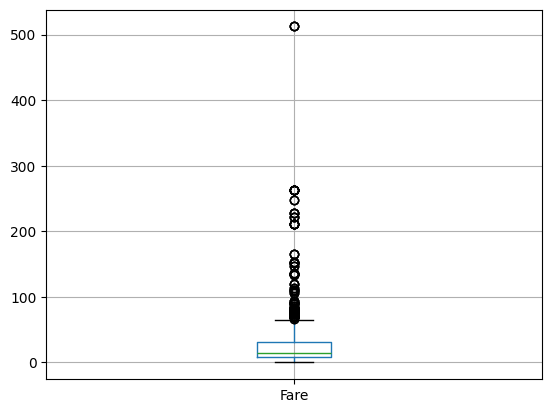

In [ ]:
test_df3.boxplot("Fare") # 이상치 탐색 연습

<Axes: >

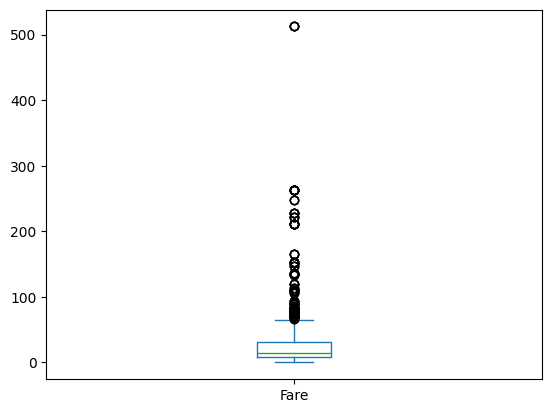

In [ ]:
test_df3["Fare"].plot(kind="box")

array([[<Axes: title={'center': 'PassengerId'}>,
        <Axes: title={'center': 'Survived'}>,
        <Axes: title={'center': 'Pclass'}>],
       [<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'SibSp'}>,
        <Axes: title={'center': 'Parch'}>],
       [<Axes: title={'center': 'Fare'}>,
        <Axes: title={'center': 'WikiId'}>,
        <Axes: title={'center': 'Age_wiki'}>],
       [<Axes: title={'center': 'Class'}>, <Axes: >, <Axes: >]],
      dtype=object)

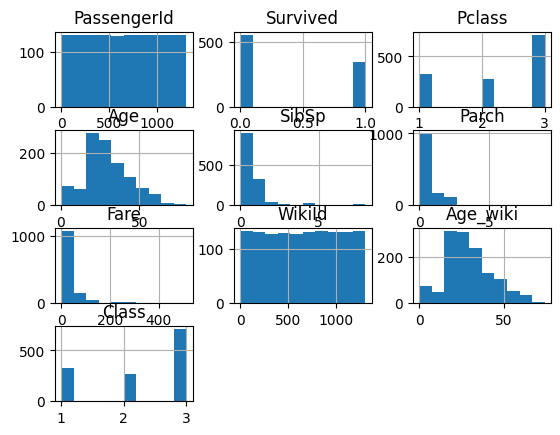

In [ ]:
test_df3.hist()    # 이상치 탐색 연습

In [ ]:
test_df3["Fare"]<=100     # Fare 100 이하 값 나타내 보기

,Fare
0,True
1,True
2,True
3,True
4,True
...,...
1304,True
1305,False
1306,True
1307,True


In [ ]:
sum(test_df3["Fare"]<=100)  # Fare 100 이하 값 합계 보기

1224

###2. 3사분위와 1사분위 범위 구하기 : 데이터의 중간 50%가 분포하는 범위

In [ ]:
IQR = test_df3["Fare"].describe()["75%"]-test_df3["Fare"].describe()["25%"]
print(IQR)

23.379199999999997


###2.zscore 값 찾기 : 어떤 데이터 값이 평균으로부터 몇 표준편차 떨어져 있는지 보여주는 값

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,WikiId,Age_wiki,Class,zscore
count,1309.000000,891.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,1304.000000,1302.000000,1304.000000,1.308000e+03
mean,655.000000,0.383838,2.294882,29.881138,0.498854,0.385027,33.295479,658.534509,29.415829,2.291411,-1.004973e-16
std,378.020061,0.486592,0.837836,14.413493,1.041658,0.865560,51.758668,380.377373,13.758954,0.840852,1.000000e+00
min,1.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000,1.000000,0.170000,1.000000,-6.432832e-01
25%,328.000000,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800,326.750000,21.000000,1.750000,-4.907329e-01
50%,655.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,661.500000,28.000000,3.000000,-3.640217e-01
75%,982.000000,1.000000,3.000000,39.000000,1.000000,0.000000,31.275000,987.250000,37.750000,3.000000,-3.903654e-02
max,1309.000000,1.000000,3.000000,80.000000,8.000000,9.000000,512.329200,1314.000000,74.000000,3.000000,9.255140e+00


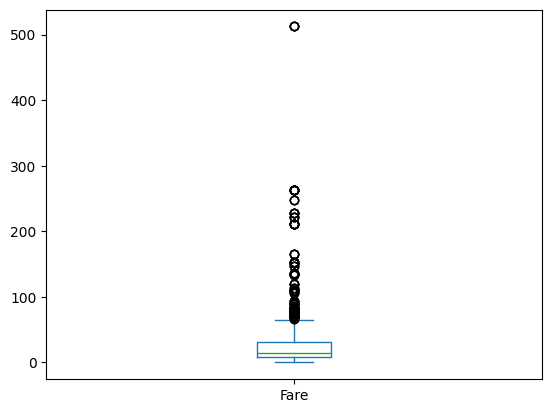

In [ ]:
test_df=df.copy() # zscore 연습
fare_std=test_df["Fare"].std()
fare_mean=test_df["Fare"].mean()
test_df["zscore"]=(test_df["Fare"]-fare_mean)/fare_std
(test_df["zscore"]<=3).mean()*100

test_df["Fare"].plot(kind='box')
test_df.describe()
